# 04i — Isentropic Single-Variable Composite Explorer

Like `04_single_var_composite.ipynb` but on **isentropic surfaces**
(315–355 K in 5 K steps).

For each NPZ event the 3-D isobaric fields are **interpolated onto θ**
before compositing, so the bootstrap CI operates on per-event isentropic
slices.

**Two modes**:
1. **2-panel** (default): composite mean + bootstrap significance (hatched non-sig)
2. **6-panel** (`projection=True`): adds 2×2 projection onto dh−1 orthogonal
   basis (INT, PRP, DEF, Residual) using **only significant** grid points.

Data: `/net/flood/data2/users/x_yan/composite_blocking_tempest/onset`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.isentropic import interp_event_field_to_single_theta

## 1  Configuration & available fields

In [2]:
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
SMOOTH_DEG = 3.0
GRID_SP    = 1.5
N_BOOT     = 1000
ALPHA      = 0.05
SEED       = 42
PV_CONTOUR = - 0 * 0.5e-6     # PV anomaly contour for mask boundary
N_CONTOUR  = 21          # number of contourf levels

# ── Isentropic target levels (K) ──
THETA_LEVELS = np.arange(315, 360, 5, dtype=float)  # 315, 320, … 355 K

# ── Discover available 3-D fields from a sample NPZ ──
_sample = np.load(f"{DATA_ROOT}/{STAGE}/dh=+0/" +
                  sorted(os.listdir(f"{DATA_ROOT}/{STAGE}/dh=+0"))[0])
levels_hpa = _sample["levels"]
fields_3d  = sorted(k for k in _sample.keys() if k.endswith("_3d"))

print(f"Isobaric levels (hPa): {levels_hpa}")
print(f"Target θ levels  (K) : {THETA_LEVELS}")
print(f"\n── 3-D isobaric fields ({len(fields_3d)}) ──")
for f in fields_3d:
    print(f"  {f}")

# Sanity-check θ range in the sample event
th = _sample["theta_3d"]
print(f"\n── Sample-event θ range per level ──")
for i, lev in enumerate(levels_hpa):
    print(f"  {lev:5d} hPa → θ = {np.nanmin(th[i]):.1f} – {np.nanmax(th[i]):.1f} K")

del _sample, th

Isobaric levels (hPa): [1000  850  700  500  400  300  250  200  100]
Target θ levels  (K) : [315. 320. 325. 330. 335. 340. 345. 350. 355.]

── 3-D isobaric fields (82) ──
  Q_3d
  pv_3d
  pv_anom_3d
  pv_anom_dp_3d
  pv_anom_dt_3d
  pv_anom_dx_3d
  pv_anom_dy_3d
  pv_bar_3d
  pv_bar_dp_3d
  pv_bar_dt_3d
  pv_bar_dx_3d
  pv_bar_dy_3d
  pv_dp_3d
  pv_dt_3d
  pv_dx_3d
  pv_dy_3d
  t_3d
  theta_3d
  theta_dot_3d
  theta_dt_3d
  u_3d
  u_anom_3d
  u_anom_div_3d
  u_anom_div_dry_3d
  u_anom_div_moist_3d
  u_anom_har_3d
  u_anom_pv_anom_dx_3d
  u_anom_pv_bar_dx_3d
  u_anom_rot_3d
  u_bar_3d
  u_bar_pv_anom_dx_3d
  u_bar_pv_bar_dx_3d
  u_div_dry_pv_anom_dx_3d
  u_div_dry_pv_bar_dx_3d
  u_div_moist_pv_anom_dx_3d
  u_div_moist_pv_bar_dx_3d
  u_div_pv_anom_dx_3d
  u_div_pv_bar_dx_3d
  u_har_pv_anom_dx_3d
  u_har_pv_bar_dx_3d
  u_rot_pv_anom_dx_3d
  u_rot_pv_bar_dx_3d
  v_3d
  v_anom_3d
  v_anom_div_3d
  v_anom_div_dry_3d
  v_anom_div_moist_3d
  v_anom_har_3d
  v_anom_pv_anom_dy_3d
  v_anom_pv_ba

## Isentropic interpolation — MetPy-aligned algorithm

Each NPZ event contains 3-D fields on $N_p$ isobaric levels
$\{p_1, p_2, \dots, p_{N_p}\}$ (here 1000, 850, 700, 500, 400, 300, 250, 200, 100 hPa).
The potential-temperature field $\theta(p)$ is also stored at every grid column
$(j, i)$.

**Goal.** Given a target isentropic level $\theta^*$ (e.g. 330 K), obtain
$\phi(\theta^*)$ for any 3-D field $\phi$ at every horizontal grid point.

### What is needed

| Quantity | Symbol | Shape | Units |
|---|---|---|---|
| Pressure levels | $p_k$ | $(N_p,)$ | hPa |
| Temperature | $T(p_k, j, i)$ | $(N_p, N_y, N_x)$ | K |
| Potential temperature | $\theta = T(P_0/p)^\kappa$ | $(N_p, N_y, N_x)$ | K |
| Target isentropic surfaces | $\theta^*$ | $(N_\theta,)$ | K |
| Field to interpolate | $\phi(p_k, j, i)$ | $(N_p, N_y, N_x)$ | various |

### Algorithm (Ziv & Alpert 1994, as in MetPy `isentropic_interpolation`)

The implementation in `pvtend.isentropic` follows MetPy v1.7 ([source](https://github.com/Unidata/MetPy/blob/v1.7.1/src/metpy/calc/thermo.py#L3023-L3190)):

1. **Sort** pressure levels in descending order (surface → top).

2. **Compute** potential temperature at every grid point:
$$\theta = T \left(\frac{P_0}{p}\right)^\kappa, \quad \kappa = R_d / c_{pd} \approx 0.286$$

3. For each target $\theta^*$, **find bounding indices** $m, m+1$ such that
   $\theta_m \leq \theta^* \leq \theta_{m+1}$.

4. **Assume** temperature varies linearly with $\ln p$ between the bounding levels:
$$T(\ln p) = a \cdot \ln p + b$$
where:
$$a = \frac{T_{m+1} - T_m}{\ln p_{m+1} - \ln p_m}, \quad
b = T_{m+1} - a \cdot \ln p_{m+1}$$

5. **Newton-Raphson** iteration to solve for $p^*$ on the $\theta^*$ surface:
$$\theta^* = T(\ln p) \cdot \left(\frac{P_0}{p}\right)^\kappa
  = (a \ln p + b) \cdot P_0^\kappa \cdot e^{-\kappa \ln p}$$

   Define:
$$f(\ln p) = \theta^* - (a \ln p + b) \cdot P_0^\kappa \cdot e^{-\kappa \ln p}$$
$$f'(\ln p) = P_0^\kappa \cdot e^{-\kappa \ln p} \cdot (\kappa T - a)$$

   Update:
$$\ln p_{n+1} = \ln p_n - \frac{f}{f'}$$

6. Once $p^*$ is known, **interpolate** additional fields linearly onto the
   isentropic surface (column-wise `np.interp` against sorted $\theta$).

If $\theta^*$ is **outside** the column's $\theta$ range → NaN (no extrapolation).

### Why this is better than simple θ-interpolation

- The Newton-Raphson approach correctly models the **non-linear Poisson relationship** between $T$ and $p$, rather than assuming $\phi$ varies linearly with $\theta$.
- Additional fields are interpolated via $\theta$ as the vertical coordinate, which is meteorologically consistent.

### Reference
Ziv, B. & Alpert, P. (1994). *Beitr. Phys. Atmosph.*, 67, 221–230.
MetPy docs: [isentropic_interpolation](https://unidata.github.io/MetPy/latest/api/generated/metpy.calc.isentropic_interpolation.html)

## 2  Core helpers

In [3]:
from zipfile import BadZipFile


def _load_npz(path):
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None


def load_events(dh, stage=STAGE):
    """Load all events at a given dh → list[dict] (skips bad files)."""
    sign = "+" if dh >= 0 else ""
    d = f"{DATA_ROOT}/{stage}/dh={sign}{dh}"
    files = sorted(glob.glob(os.path.join(d, "track_*.npz")))
    if not files:
        return []
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(_load_npz, files))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ dh={dh}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good


# ─────────────────────────────────────────────────────
# Isentropic field extraction (using pvtend.isentropic)
# ─────────────────────────────────────────────────────
def get_field_isen(event, var_spec, theta_level):
    """Extract a 2-D isentropic field from one event.

    Uses ``pvtend.isentropic.interp_event_field_to_single_theta``
    which follows the MetPy / Ziv-Alpert (1994) algorithm:
      - column-wise interpolation with θ sorted ascending
      - NaN for out-of-range θ* (no extrapolation)

    Parameters
    ----------
    event : dict — loaded NPZ event.
    var_spec : str or list[str]
        Field name(s) with optional '-' prefix for negation.  Summed.
        '_3d' suffix is appended automatically.
    theta_level : float (K)

    Returns
    -------
    (ny, nx) array.
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    theta_3d = event["theta_3d"]   # (nlev, ny, nx)

    total = None
    for vs in var_spec:
        negate = vs.startswith("-")
        name = vs.lstrip("-").strip()
        key_3d = name if name.endswith("_3d") else name + "_3d"

        # Interpolate using the MetPy-aligned pvtend function
        arr = interp_event_field_to_single_theta(
            theta_3d, event[key_3d], theta_level)

        if negate:
            arr = -arr
        total = arr.copy() if total is None else total + arr
    return total


def bootstrap_sig_isen(events, var_spec, theta_level,
                       n_boot=N_BOOT, alpha=ALPHA, seed=SEED):
    """Composite mean + bootstrap CI on an isentropic surface.

    Returns (mean_2d, sig_mask) — sig_mask=True where CI excludes zero.
    """
    print(f"  Interpolating {len(events)} events to θ={theta_level} K ...")
    stack = np.array([get_field_isen(e, var_spec, theta_level) for e in events])
    N = stack.shape[0]
    rng = np.random.default_rng(seed)

    boot = np.empty((n_boot, *stack.shape[1:]))
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boot[b] = np.nanmean(stack[idx], axis=0)

    lo = np.percentile(boot, 100 * alpha / 2, axis=0)
    hi = np.percentile(boot, 100 * (1 - alpha / 2), axis=0)
    mean = np.nanmean(stack, axis=0)
    sig_mask = ~((lo <= 0) & (hi >= 0))
    return mean, sig_mask


print("Helpers defined (using pvtend.isentropic).")

Helpers defined (using pvtend.isentropic).


## 2b  Sanity check — 3-D θ structure & isentropic interpolation

Event shape: (9, 29, 49)  (nlev=9, ny=29, nx=49)
Pressure levels: [1000  850  700  500  400  300  250  200  100]


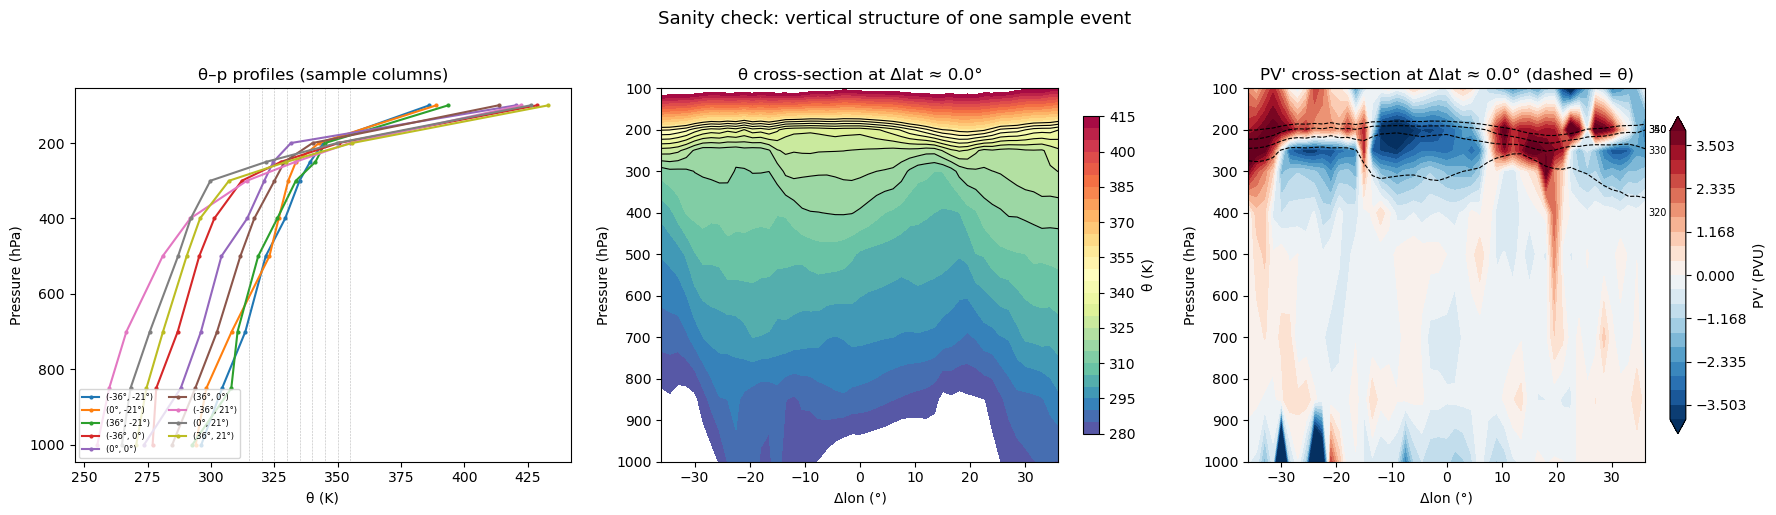

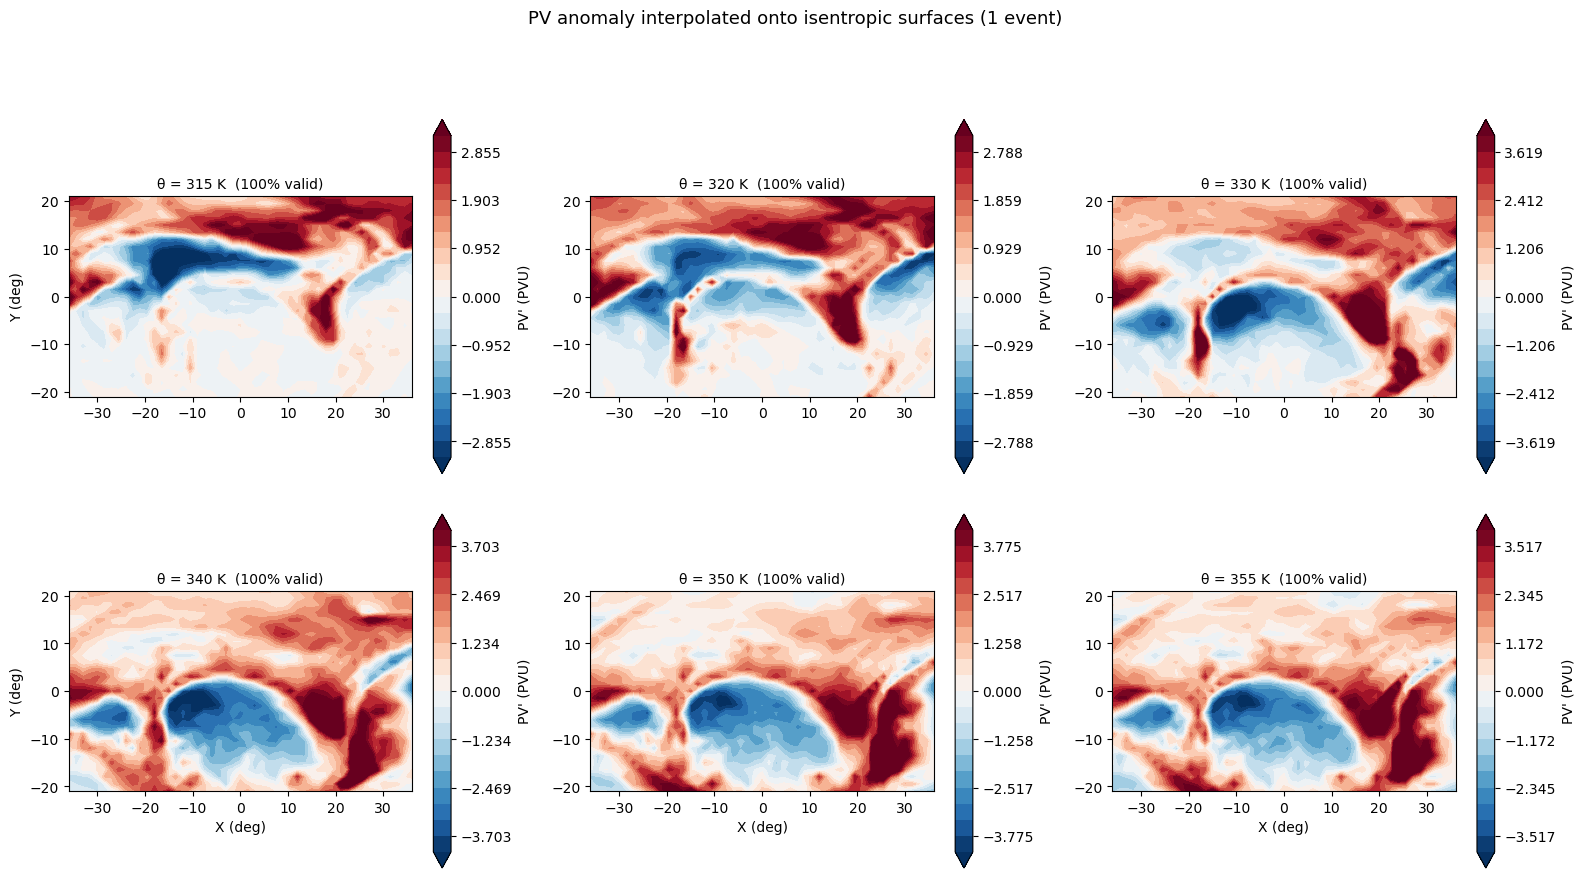

Sanity check complete.


In [4]:
# ── Load one sample event for visualization ──────────────────────────
_ev = load_events(dh=0)[0]
theta_3d = _ev["theta_3d"]          # (nlev, ny, nx)
pv_3d    = _ev["pv_anom_3d"]        # (nlev, ny, nx)
X_rel    = _ev["X_rel"]
Y_rel    = _ev["Y_rel"]
x_rel    = X_rel[0, :]
y_rel    = Y_rel[:, 0]
nlev, ny, nx = theta_3d.shape

print(f"Event shape: {theta_3d.shape}  (nlev={nlev}, ny={ny}, nx={nx})")
print(f"Pressure levels: {levels_hpa}")

# ── Panel 1: θ(p) profiles at 9 grid points (3×3 sub-grid) ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) θ–p profiles at selected columns
ax = axes[0]
jj = np.linspace(0, ny - 1, 3, dtype=int)
ii = np.linspace(0, nx - 1, 3, dtype=int)
for j in jj:
    for i in ii:
        th_col = theta_3d[:, j, i]
        ax.plot(th_col, levels_hpa, marker=".", ms=4,
                label=f"({x_rel[i]:.0f}°, {y_rel[j]:.0f}°)")
# Overlay target θ levels as horizontal bands
for tl in THETA_LEVELS:
    ax.axvline(tl, color="grey", lw=0.4, ls=":")
ax.set_xlabel("θ (K)")
ax.set_ylabel("Pressure (hPa)")
ax.invert_yaxis()
ax.set_title("θ–p profiles (sample columns)")
ax.legend(fontsize=6, ncol=2, loc="lower left")

# (b) Cross-section: θ along the central latitude (y_rel ≈ 0)
ax = axes[1]
j_mid = ny // 2
th_slice = theta_3d[:, j_mid, :]   # (nlev, nx)
cf = ax.contourf(x_rel, levels_hpa, th_slice,
                 levels=np.arange(280, 420, 5), cmap="Spectral_r")
for tl in THETA_LEVELS:
    ax.contour(x_rel, levels_hpa, th_slice, levels=[tl],
               colors="k", linewidths=0.8)
ax.invert_yaxis()
ax.set_xlabel("Δlon (°)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"θ cross-section at Δlat ≈ {y_rel[j_mid]:.1f}°")
plt.colorbar(cf, ax=ax, label="θ (K)", shrink=0.85)

# (c) Cross-section: PV anomaly along central latitude
ax = axes[2]
pv_slice = pv_3d[:, j_mid, :] * 1e6  # → PVU
vmax_pv = np.nanpercentile(np.abs(pv_slice), 95)
cf2 = ax.contourf(x_rel, levels_hpa, pv_slice,
                  levels=np.linspace(-vmax_pv, vmax_pv, 21),
                  cmap="RdBu_r", extend="both")
for tl in [320, 330, 340, 350]:
    ax.contour(x_rel, levels_hpa, th_slice, levels=[tl],
               colors="k", linewidths=0.8, linestyles="--")
    # Label the θ contour
    ax.text(x_rel[-1] + 0.5, levels_hpa[np.argmin(np.abs(th_slice[:, -1] - tl))],
            f"{tl}", fontsize=7, va="center")
ax.invert_yaxis()
ax.set_xlabel("Δlon (°)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"PV' cross-section at Δlat ≈ {y_rel[j_mid]:.1f}° (dashed = θ)")
plt.colorbar(cf2, ax=ax, label="PV' (PVU)", shrink=0.85)

fig.suptitle("Sanity check: vertical structure of one sample event", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# ── Panel 2: PV anomaly interpolated onto multiple θ surfaces ────────
theta_show = [315, 320, 330, 340, 350, 355]
n_th = len(theta_show)
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))

for idx, tl in enumerate(theta_show):
    ax = axes2.flat[idx]
    pv_isen = get_field_isen(_ev, "pv_anom", tl)
    valid_frac = 100 * np.mean(np.isfinite(pv_isen))
    pv_isen_pvu = pv_isen * 1e6
    vmax_i = np.nanpercentile(np.abs(pv_isen_pvu[np.isfinite(pv_isen_pvu)]), 95) \
             if np.any(np.isfinite(pv_isen_pvu)) else 1.0
    vmax_i = max(vmax_i, 1e-6)
    im = ax.contourf(X_rel, Y_rel, pv_isen_pvu,
                     levels=np.linspace(-vmax_i, vmax_i, 21),
                     cmap="RdBu_r", extend="both")
    ax.set_title(f"θ = {tl} K  ({valid_frac:.0f}% valid)", fontsize=10)
    ax.set_aspect("equal")
    if idx % 3 == 0:
        ax.set_ylabel("Y (deg)")
    if idx >= 3:
        ax.set_xlabel("X (deg)")
    plt.colorbar(im, ax=ax, shrink=0.8, label="PV' (PVU)")

fig2.suptitle("PV anomaly interpolated onto isentropic surfaces (1 event)",
              fontsize=13, y=1.02)
fig2.tight_layout()
plt.show()

del _ev
print("Sanity check complete.")

## 3  Main plotting function

In [5]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)


def plot_var(var_spec, dh=0, theta_level=330.0, projection=False,
             n_boot=N_BOOT, alpha=ALPHA, seed=SEED, figsize_scale=1.0):
    """Composite + bootstrap plot on an isentropic surface.

    Parameters
    ----------
    var_spec : str or list[str]
        Field name(s) with optional '-' prefix for negation.  Summed.
    dh : int
        Lifecycle hour.
    theta_level : float
        Isentropic level (K).
    projection : bool
        If True, add 2×2 projection rows (3-row / 6-panel figure).
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    # ── 1. Load events ──
    evs = load_events(dh)
    N = len(evs)
    if N == 0:
        print(f"No events at dh={dh}")
        return
    X_rel = evs[0]["X_rel"]
    Y_rel = evs[0]["Y_rel"]
    x_rel = X_rel[0, :]
    y_rel = Y_rel[:, 0]

    # ── 2. Composite mean + bootstrap on θ surface ──
    print(f"Computing bootstrap (N={N}, n_boot={n_boot}, θ={theta_level} K) ...")
    mean_fld, sig_mask = bootstrap_sig_isen(evs, var_spec, theta_level,
                                            n_boot, alpha, seed)
    pct_sig = 100 * np.nanmean(sig_mask)
    print(f"  {pct_sig:.1f}% significant at {100*(1-alpha):.0f}%")

    # PV anomaly composite on the same θ surface (for contour)
    pv_anom_mean = np.nanmean(
        [get_field_isen(e, "pv_anom", theta_level) for e in evs], axis=0)

    # ── Label ──
    var_label = " + ".join(var_spec)

    # ── 3. Projection (if requested) ──
    proj = None
    if projection:
        dh_basis = max(dh - 1, -13)
        evs_b = load_events(dh_basis) if dh_basis != dh else evs

        # Basis fields on the same θ surface from dh−1 composite mean
        pv_b = np.nanmean(
            [get_field_isen(e, "pv_anom", theta_level) for e in evs_b], axis=0)
        dx_b = np.nanmean(
            [get_field_isen(e, "pv_anom_dx", theta_level) for e in evs_b], axis=0)
        dy_b = np.nanmean(
            [get_field_isen(e, "pv_anom_dy", theta_level) for e in evs_b], axis=0)

        basis = compute_orthogonal_basis(
            pv_b, dx_b, dy_b, x_rel, y_rel,
            mask_negative=True,
            apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
        )

        # Project sig-only field
        field_sig = np.where(sig_mask, mean_fld, 0.0)
        field_sig_s = smooth(field_sig)
        proj = project_field(field_sig_s, basis)
        print(f"  Projection (sig-only): "
              f"β={proj['beta']:.3e}  αx={proj['ax']:.3f}  "
              f"αy={proj['ay']:.3f}  γ={proj['gamma']:.3e}")

    # ── 4. Plot ──
    n_rows = 3 if projection else 1
    fig = plt.figure(figsize=(14 * figsize_scale, 5 * n_rows * figsize_scale))
    gs = GridSpec(n_rows, 2, figure=fig, hspace=0.35, wspace=0.25)

    # Colour scale
    finite = mean_fld[np.isfinite(mean_fld)]
    if finite.size == 0:
        print("⚠ No finite values — θ level may be out of range for most events.")
        return None
    vmax = float(np.nanpercentile(np.abs(finite), 95))
    vmax = max(vmax, 1e-30)
    clevels = np.linspace(-vmax, vmax, N_CONTOUR)

    # --- Row 1, Left: Composite mean ---
    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                        cmap="RdBu_r", extend="both")
    ax0.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    ax0.set_title(f"Composite Mean  (N={N})", fontsize=11, fontweight="bold")
    ax0.set_ylabel("Y (deg)"); ax0.set_xlabel("X (deg)")
    ax0.set_aspect("equal")
    plt.colorbar(im0, ax=ax0, shrink=0.85)

    # --- Row 1, Right: Bootstrap significance ---
    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                        cmap="RdBu_r", extend="both")
    ax1.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    ax1.contourf(X_rel, Y_rel, (~sig_mask).astype(float),
                 levels=[0.5, 1.5], hatches=["xxx"], colors="none", zorder=5)
    ax1.set_title(f"Bootstrap sig ({100*(1-alpha):.0f}%)  "
                  f"Hatch=n.s.  ({pct_sig:.0f}% sig)",
                  fontsize=11, fontweight="bold")
    ax1.set_xlabel("X (deg)")
    ax1.set_aspect("equal")
    plt.colorbar(im1, ax=ax1, shrink=0.85)

    # --- Rows 2-3: Projection (2×2) ---
    if projection and proj is not None:
        panels = [
            ("INT (β · Φ₁)",           proj["int"]),
            ("PRP (αx·Φ₂ + αy·Φ₃)",   proj["prop"]),
            ("DEF (γ · Φ₄)",           proj["def"]),
            ("Residual",               proj["resid"]),
        ]
        all_abs = np.concatenate([
            np.abs(p[np.isfinite(p)]) for _, p in panels if np.any(np.isfinite(p))
        ])
        vmax_p = float(np.percentile(all_abs, 95)) if all_abs.size else 1e-30
        vmax_p = max(vmax_p, 1e-30)
        clev_p = np.linspace(-vmax_p, vmax_p, N_CONTOUR)

        coef_txt = (f"β={proj['beta']:.3e} s⁻¹   "
                    f"αx={proj['ax']:.3f} m/s   "
                    f"αy={proj['ay']:.3f} m/s   "
                    f"γ={proj['gamma']:.3e} s⁻¹   "
                    f"RMSE/max={proj['rmse']/(np.nanmax(np.abs(mean_fld))+1e-30):.3f}")

        for idx, (label, field) in enumerate(panels):
            row = 1 + idx // 2
            col = idx % 2
            ax = fig.add_subplot(gs[row, col])
            im = ax.contourf(X_rel, Y_rel, field, levels=clev_p,
                             cmap="RdBu_r", extend="both")
            ax.contour(X_rel, Y_rel, pv_anom_mean,
                       levels=[PV_CONTOUR], colors="white", linewidths=2.0)
            ax.set_title(label, fontsize=10, fontweight="bold")
            ax.set_xlabel("X (deg)")
            if col == 0:
                ax.set_ylabel("Y (deg)")
            ax.set_aspect("equal")
            plt.colorbar(im, ax=ax, shrink=0.75)

        fig.text(0.5, 1 - 1.0 / n_rows - 0.01, coef_txt,
                 ha="center", fontsize=10, fontstyle="italic",
                 transform=fig.transFigure)

    sign_str = "+" if dh >= 0 else ""
    fig.suptitle(
        f"{STAGE}  dh={sign_str}{dh}   θ={theta_level:.0f} K   N={N}\n"
        f"Field: {var_label}",
        fontsize=12, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    plt.show()
    return proj


print("plot_var() defined.")

plot_var() defined.


## 4  Examples

Computing bootstrap (N=1134, n_boot=1000, θ=330 K) ...
  Interpolating 1134 events to θ=330 K ...
  50.7% significant at 95%
  Projection (sig-only): β=1.474e-06  αx=0.047  αy=-0.234  γ=-1.258e+05


/tmp/ipykernel_2082558/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


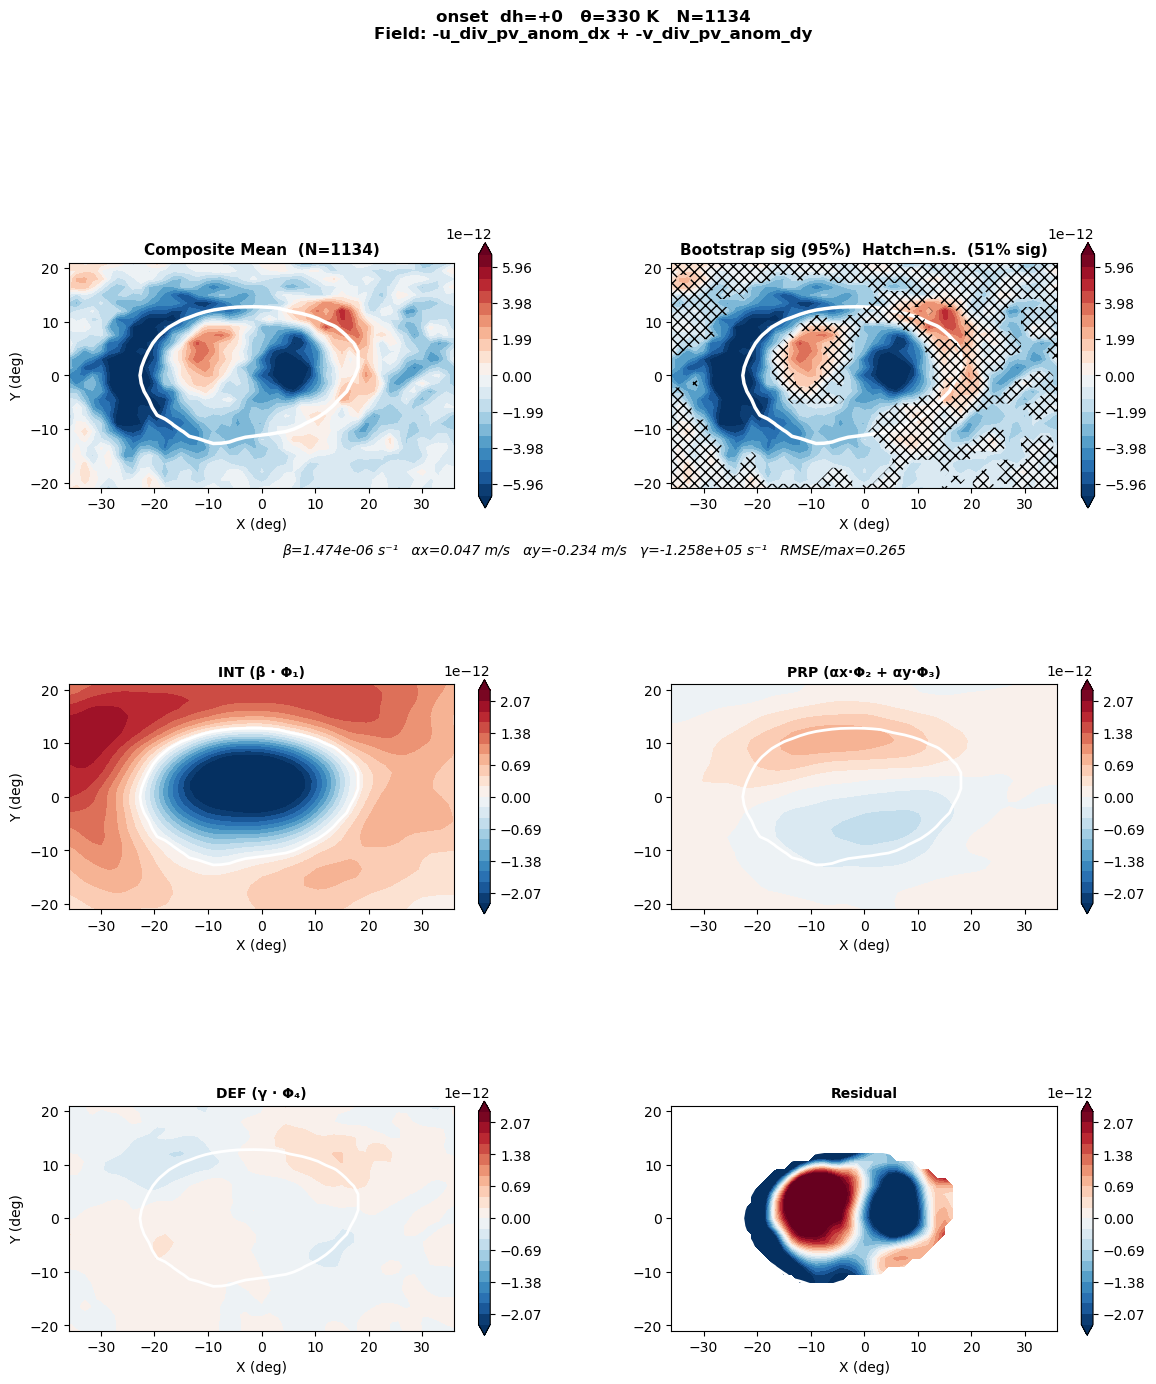

{'beta': 1.4742890424446036e-06,
 'ax': 0.04733605995033817,
 'ay': -0.23435511830073272,
 'gamma': -125820.27383134898,
 'gamma_km2': -0.12582027383134897,
 'beta_raw': 1.4742890424446036e-12,
 'ax_raw': 4.733605995033817e-14,
 'ay_raw': -2.343551183007327e-13,
 'gamma_raw': -1.2582027383134899e-13,
 'prop': array([[ 6.18210896e-14,  6.30540067e-14,  6.75973938e-14, ...,
          3.01785803e-14,  2.97289981e-14,  3.51852570e-14],
        [ 5.55493631e-14,  6.14443326e-14,  6.89472597e-14, ...,
          3.18700506e-14,  3.06700930e-14,  2.94143449e-14],
        [ 5.72436293e-14,  6.36755680e-14,  6.80545210e-14, ...,
          3.79647983e-14,  2.85900829e-14,  1.82788840e-14],
        ...,
        [-1.60639403e-13, -1.56070909e-13, -1.48817893e-13, ...,
          1.34429839e-13,  1.33138482e-13,  1.30509930e-13],
        [-1.58132886e-13, -1.54380070e-13, -1.48696768e-13, ...,
          1.12662581e-13,  1.26221912e-13,  1.29053001e-13],
        [-1.39224041e-13, -1.39709642e-13, -1.3

In [6]:
# 6-panel: divergent outflow on 330 K with projection
plot_var(["-u_div_pv_anom_dx", "-v_div_pv_anom_dy"],
         dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1134, n_boot=1000, θ=320 K) ...
  Interpolating 1134 events to θ=320 K ...
  94.7% significant at 95%


/tmp/ipykernel_2082558/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


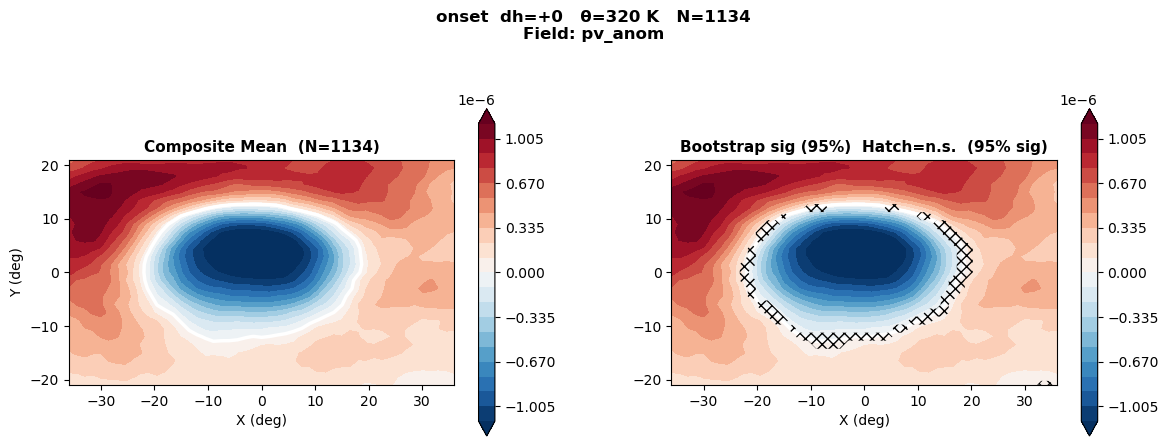

In [8]:
# 2-panel: PV anomaly on 320 K
plot_var(["pv_anom"], dh=0, theta_level=320, projection=False)

Computing bootstrap (N=1134, n_boot=1000, θ=330 K) ...
  Interpolating 1134 events to θ=330 K ...
  56.7% significant at 95%
  Projection (sig-only): β=1.373e-06  αx=17.578  αy=-0.373  γ=-3.303e+06


/tmp/ipykernel_2777490/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


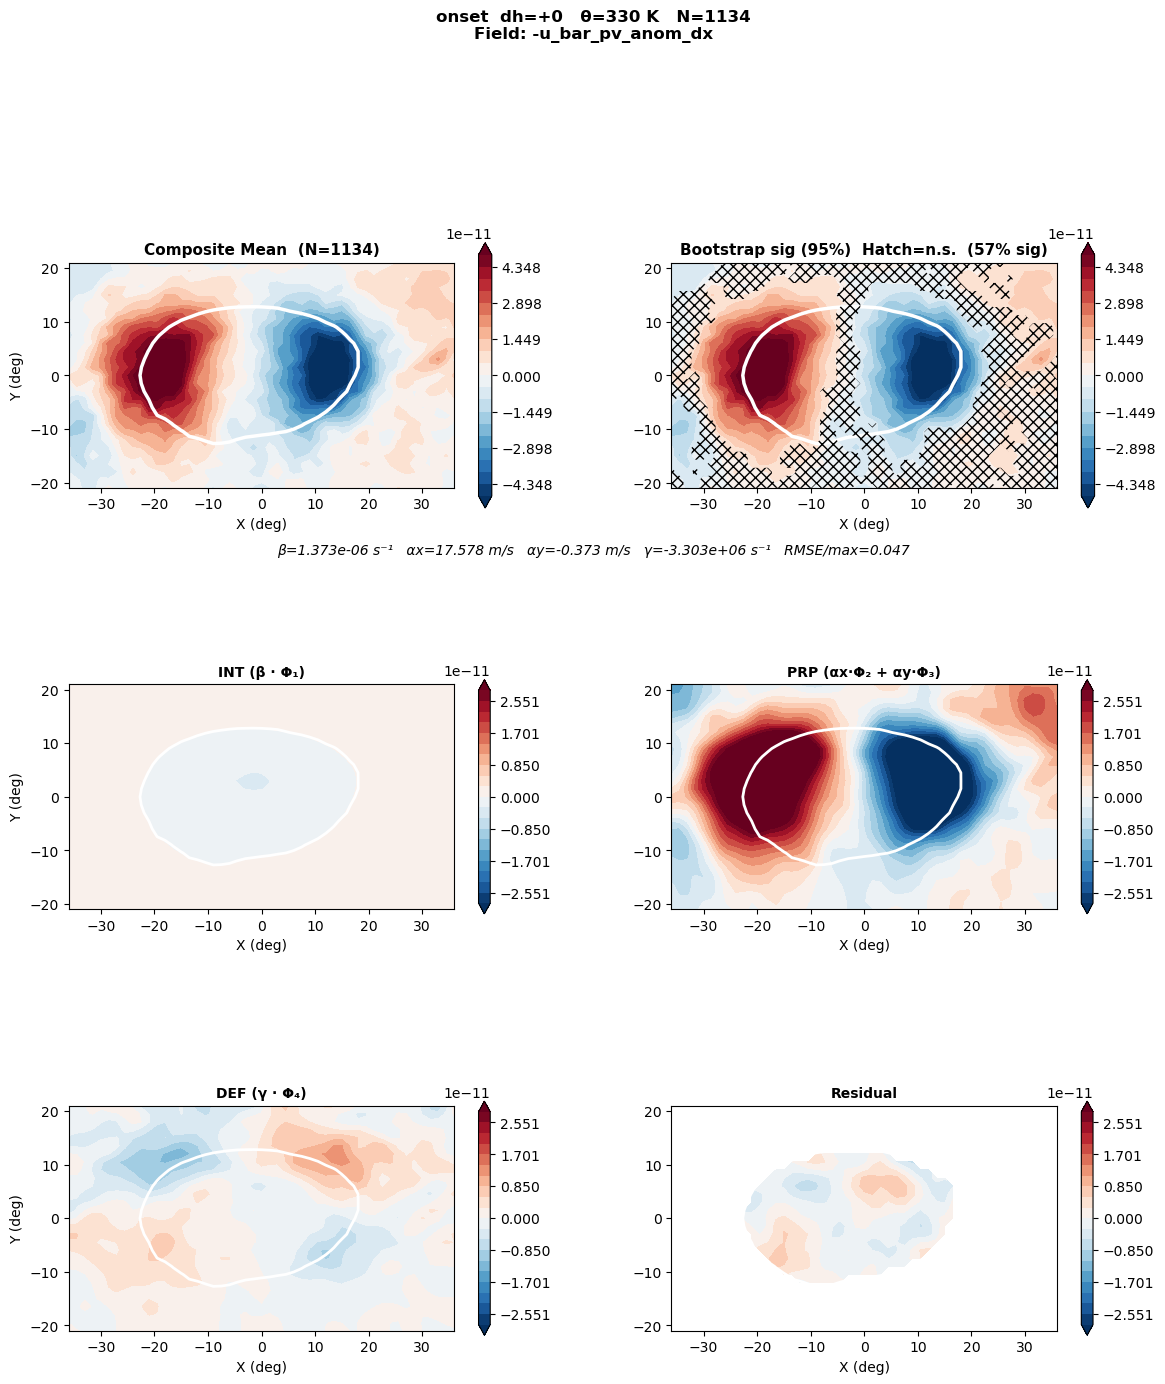

{'beta': 1.3727650754638552e-06,
 'ax': 17.57790053281378,
 'ay': -0.37335905570561156,
 'gamma': -3302637.6782592093,
 'gamma_km2': -3.302637678259209,
 'beta_raw': 1.3727650754638553e-12,
 'ax_raw': 1.757790053281378e-11,
 'ay_raw': -3.7335905570561155e-13,
 'gamma_raw': -3.302637678259209e-12,
 'prop': array([[-3.89159203e-12, -4.20899384e-12, -4.41593864e-12, ...,
          2.78682942e-13, -8.20469764e-13, -1.65188447e-12],
        [-3.95971105e-12, -4.72868077e-12, -4.98711260e-12, ...,
         -2.38950880e-13, -1.04017013e-12, -1.64049949e-12],
        [-4.51853319e-12, -5.91484821e-12, -6.04857503e-12, ...,
         -1.13302605e-13, -2.79381096e-13, -5.55374632e-13],
        ...,
        [-1.30660579e-11, -1.31576598e-11, -1.24457681e-11, ...,
          1.82421935e-11,  1.55981100e-11,  1.33241916e-11],
        [-1.46378772e-11, -1.43049420e-11, -1.29169970e-11, ...,
          1.63152019e-11,  1.49615006e-11,  1.32032456e-11],
        [-1.61627711e-11, -1.55721943e-11, -1.33654

In [ ]:
# 6-panel: mean-wind advection on 330 K
plot_var(["-u_bar_pv_anom_dx"], dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1134, n_boot=1000, θ=330 K) ...
  Interpolating 1134 events to θ=330 K ...
  17.5% significant at 95%
  Projection (sig-only): β=1.998e-06  αx=-0.391  αy=0.883  γ=5.564e+05


/tmp/ipykernel_2777490/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


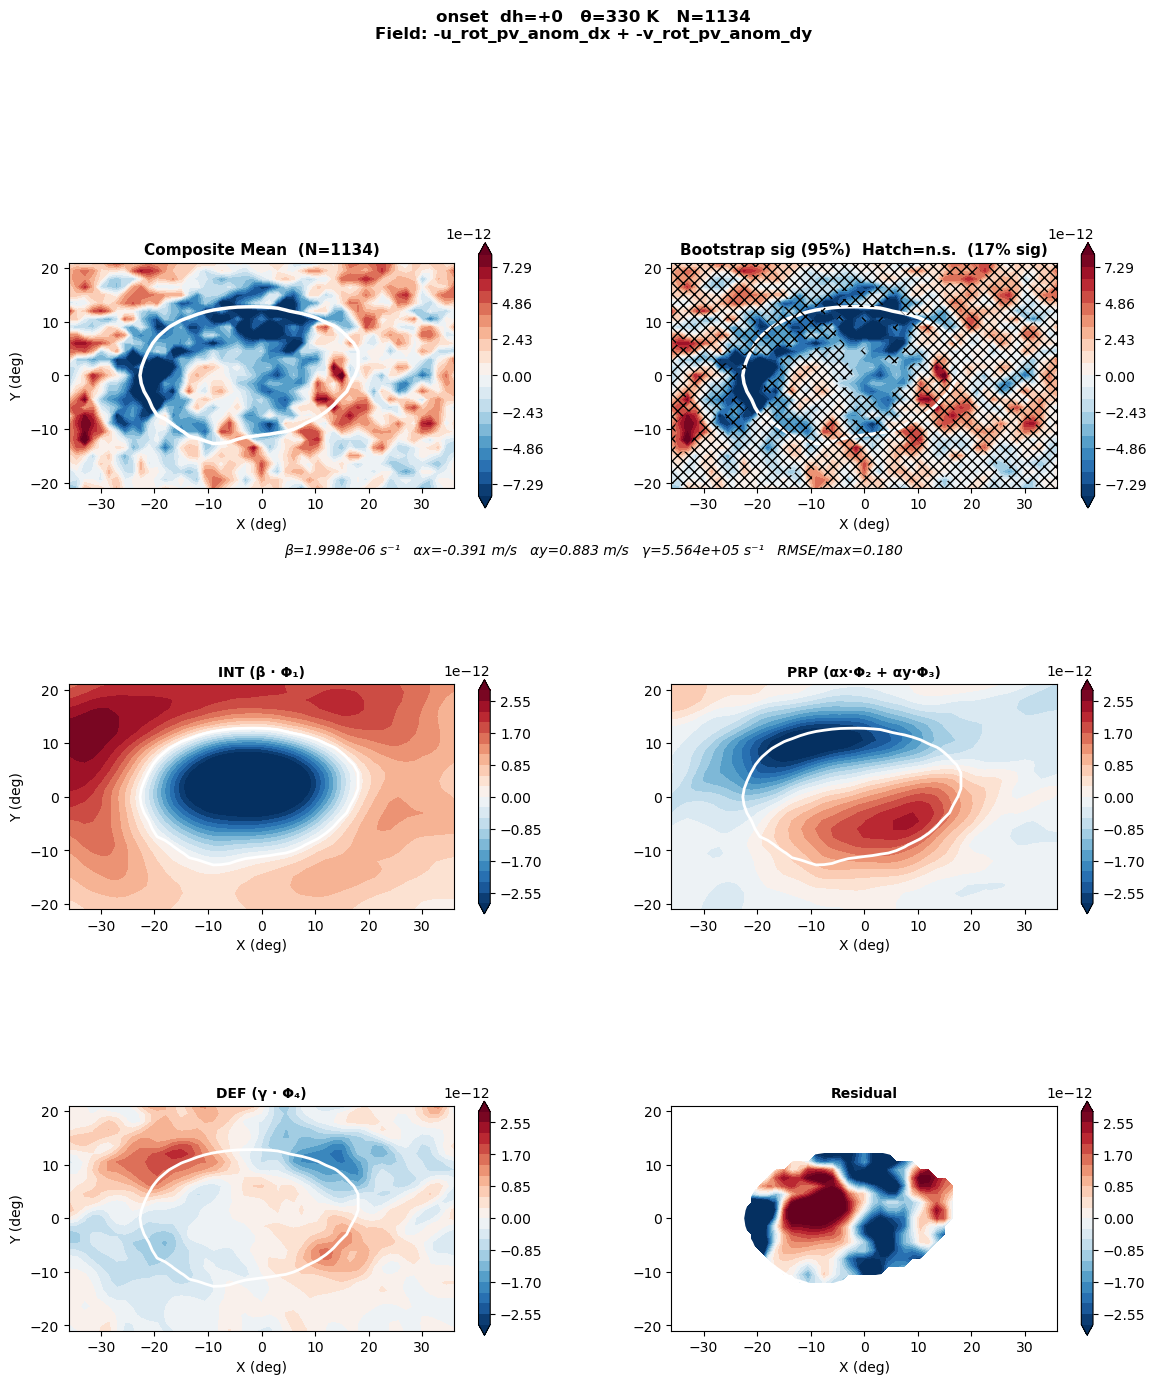

{'beta': 1.99754444884201e-06,
 'ax': -0.39132869345919896,
 'ay': 0.8831038512782062,
 'gamma': 556417.3551389597,
 'gamma_km2': 0.5564173551389597,
 'beta_raw': 1.99754444884201e-12,
 'ax_raw': -3.9132869345919897e-13,
 'ay_raw': 8.831038512782062e-13,
 'gamma_raw': 5.564173551389597e-13,
 'prop': array([[-1.84408093e-13, -1.85168231e-13, -1.99682757e-13, ...,
         -1.16525615e-13, -1.01466634e-13, -1.11805351e-13],
        [-1.60067545e-13, -1.72810697e-13, -1.97793631e-13, ...,
         -1.16568543e-13, -1.02321524e-13, -9.03096157e-14],
        [-1.59619809e-13, -1.66742966e-13, -1.81531908e-13, ...,
         -1.40945593e-13, -1.03780529e-13, -6.17673803e-14],
        ...,
        [ 7.61189112e-13,  7.45177069e-13,  7.09324931e-13, ...,
         -7.25912372e-13, -6.88900293e-13, -6.51379127e-13],
        [ 7.70917143e-13,  7.52797543e-13,  7.14604373e-13, ...,
         -6.20864273e-13, -6.55225412e-13, -6.44445757e-13],
        [ 7.18584434e-13,  7.13219234e-13,  6.75482487e-1

In [ ]:
# 6-panel: rotational eddy advection on 330 K
plot_var(["-u_rot_pv_anom_dx", "-v_rot_pv_anom_dy"],
         dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1134, n_boot=1000, θ=335 K) ...
  Interpolating 1134 events to θ=335 K ...
  22.1% significant at 95%
  Projection (sig-only): β=-6.419e-07  αx=-0.581  αy=0.092  γ=2.333e+05


/tmp/ipykernel_2777490/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


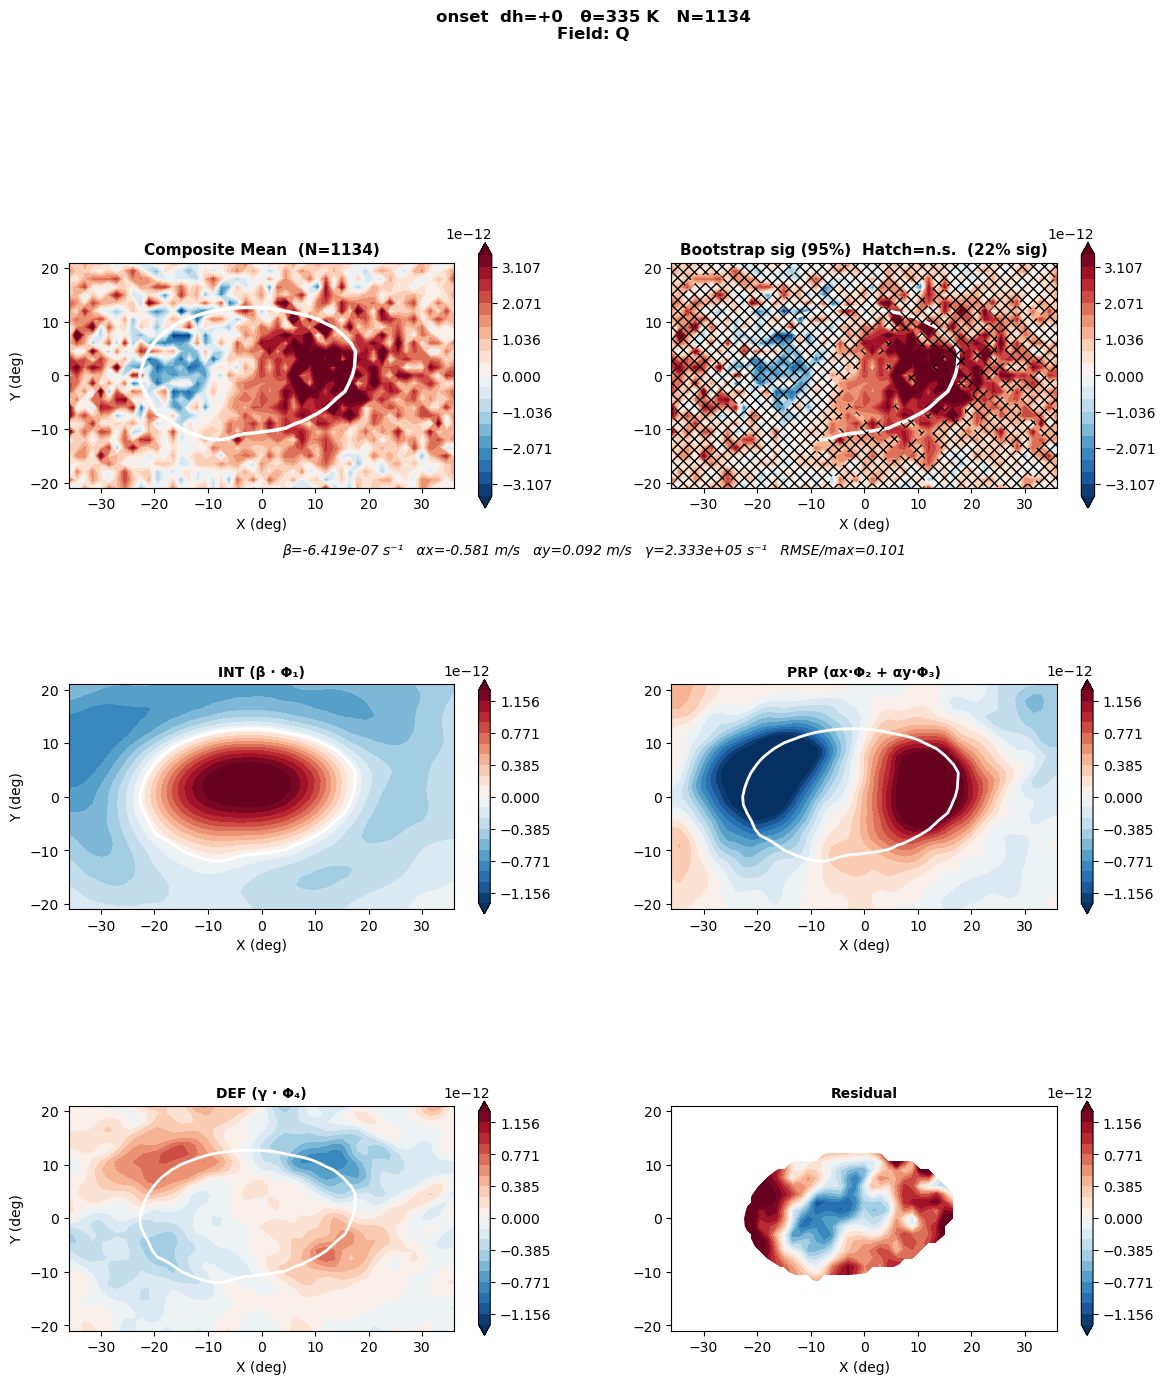

{'beta': -6.419292100696989e-07,
 'ax': -0.580859295007832,
 'ay': 0.09219991774636706,
 'gamma': 233327.35293118004,
 'gamma_km2': 0.23332735293118004,
 'beta_raw': -6.419292100696989e-13,
 'ax_raw': -5.808592950078319e-13,
 'ay_raw': 9.219991774636706e-14,
 'gamma_raw': 2.3332735293118004e-13,
 'prop': array([[ 1.65782617e-13,  1.49792041e-13,  1.17733417e-13, ...,
         -3.02680545e-14,  1.25348501e-14,  4.33426388e-14],
        [ 1.70487229e-13,  1.83495603e-13,  1.70951243e-13, ...,
         -3.37279325e-14,  7.69873921e-15,  3.86529726e-14],
        [ 1.86186631e-13,  2.27460789e-13,  2.26796427e-13, ...,
         -4.23440535e-14, -1.99028624e-14,  4.14064581e-15],
        ...,
        [ 4.20298365e-13,  4.13306976e-13,  3.86140283e-13, ...,
         -5.51734153e-13, -4.74941582e-13, -4.17430980e-13],
        [ 4.74853354e-13,  4.50609712e-13,  4.07060816e-13, ...,
         -5.07076456e-13, -4.60390907e-13, -3.97663579e-13],
        [ 5.05882687e-13,  4.87929321e-13,  4.335606

In [ ]:
# 6-panel: diabatic Q on 335 K
plot_var(["Q"], dh=0, theta_level=335, projection=True)

Computing bootstrap (N=1134, n_boot=1000, θ=340 K) ...
  Interpolating 1134 events to θ=340 K ...
  53.3% significant at 95%
  Projection (sig-only): β=1.589e-06  αx=0.395  αy=-0.386  γ=-8.333e+04


/tmp/ipykernel_2777490/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


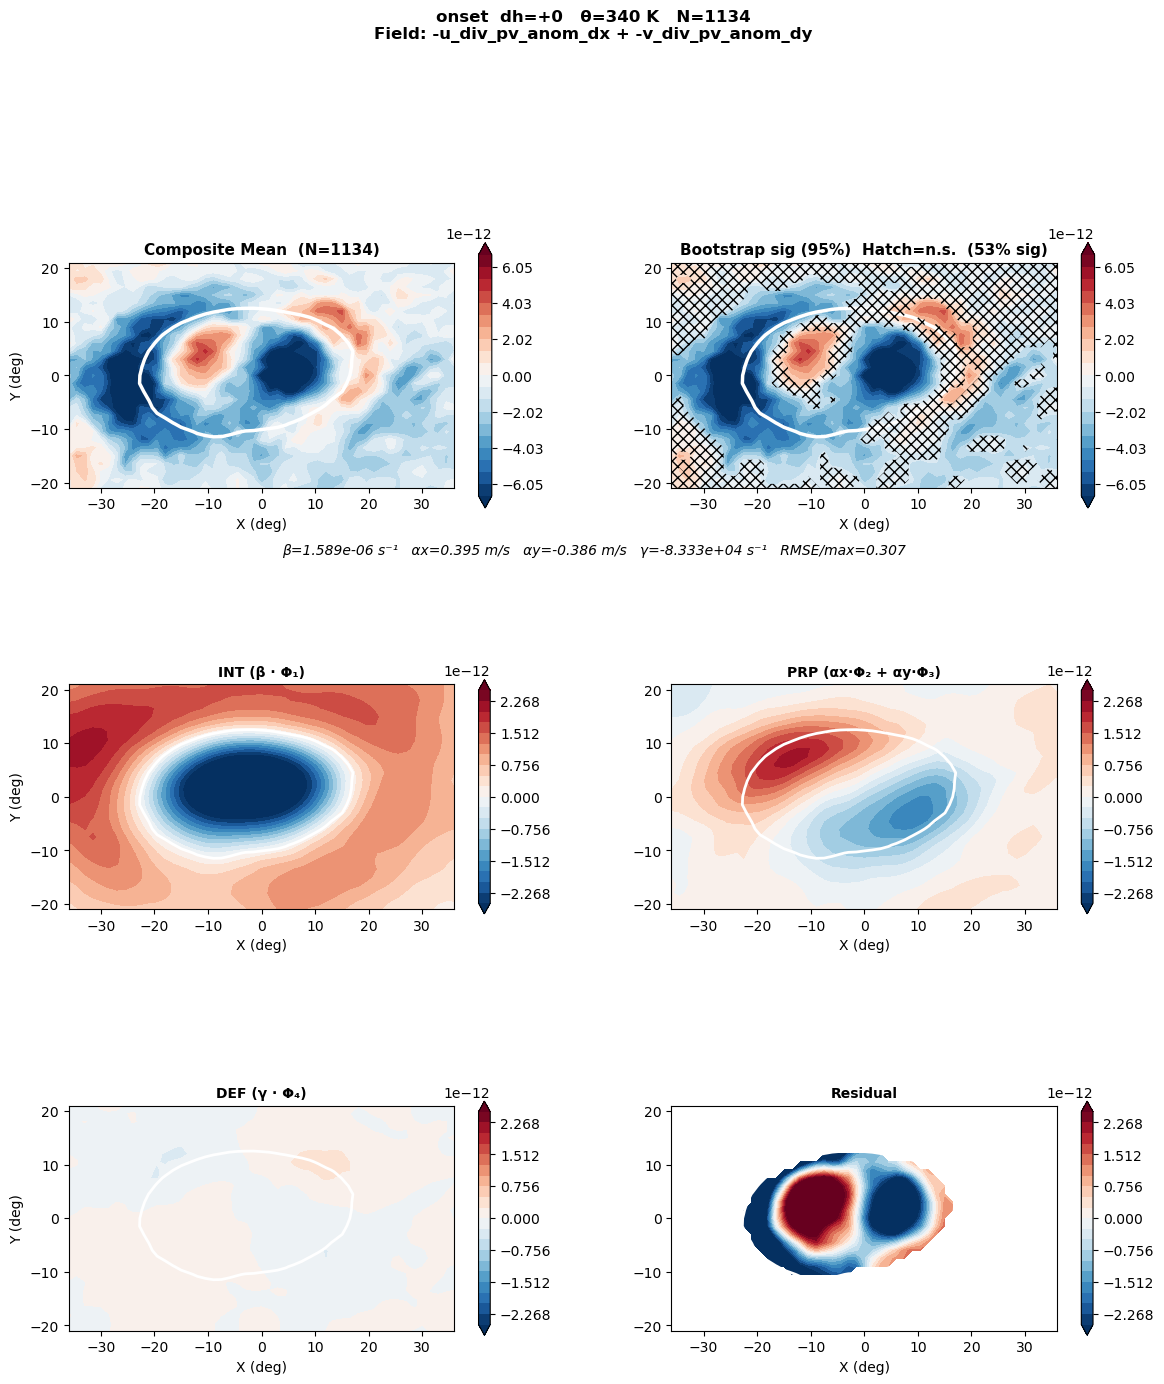

{'beta': 1.589047584436357e-06,
 'ax': 0.3954711519190369,
 'ay': -0.386099972249726,
 'gamma': -83328.15491418756,
 'gamma_km2': -0.08332815491418756,
 'beta_raw': 1.589047584436357e-12,
 'ax_raw': 3.954711519190369e-13,
 'ay_raw': -3.8609997224972597e-13,
 'gamma_raw': -8.332815491418755e-14,
 'prop': array([[ 2.96529602e-14,  5.69139370e-14,  1.12034831e-13, ...,
          7.18363110e-14,  4.62410824e-14,  2.20189183e-14],
        [ 1.31455806e-14,  2.10365727e-14,  6.52558057e-14, ...,
          7.45725760e-14,  5.17394833e-14,  2.45168064e-14],
        [ 3.26039482e-15, -1.40635796e-14,  8.94512026e-15, ...,
          9.60545765e-14,  7.28215561e-14,  4.35836451e-14],
        ...,
        [-3.78056341e-13, -3.71628873e-13, -3.60486710e-13, ...,
          3.51925548e-13,  3.14569282e-13,  2.87289702e-13],
        [-4.14910876e-13, -3.97924927e-13, -3.74707812e-13, ...,
          2.99308553e-13,  2.88139662e-13,  2.49728947e-13],
        [-4.18649864e-13, -4.12634187e-13, -3.8602803

In [ ]:
# 6-panel: divergent outflow on 340 K
plot_var(["-u_div_pv_anom_dx", "-v_div_pv_anom_dy"],
         dh=0, theta_level=340, projection=True)

Computing bootstrap (N=1134, n_boot=1000, θ=330 K) ...
  Interpolating 1134 events to θ=330 K ...
  77.2% significant at 95%
  Projection (sig-only): β=-5.973e-08  αx=-5.871  αy=0.306  γ=1.300e+06


/tmp/ipykernel_2777490/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


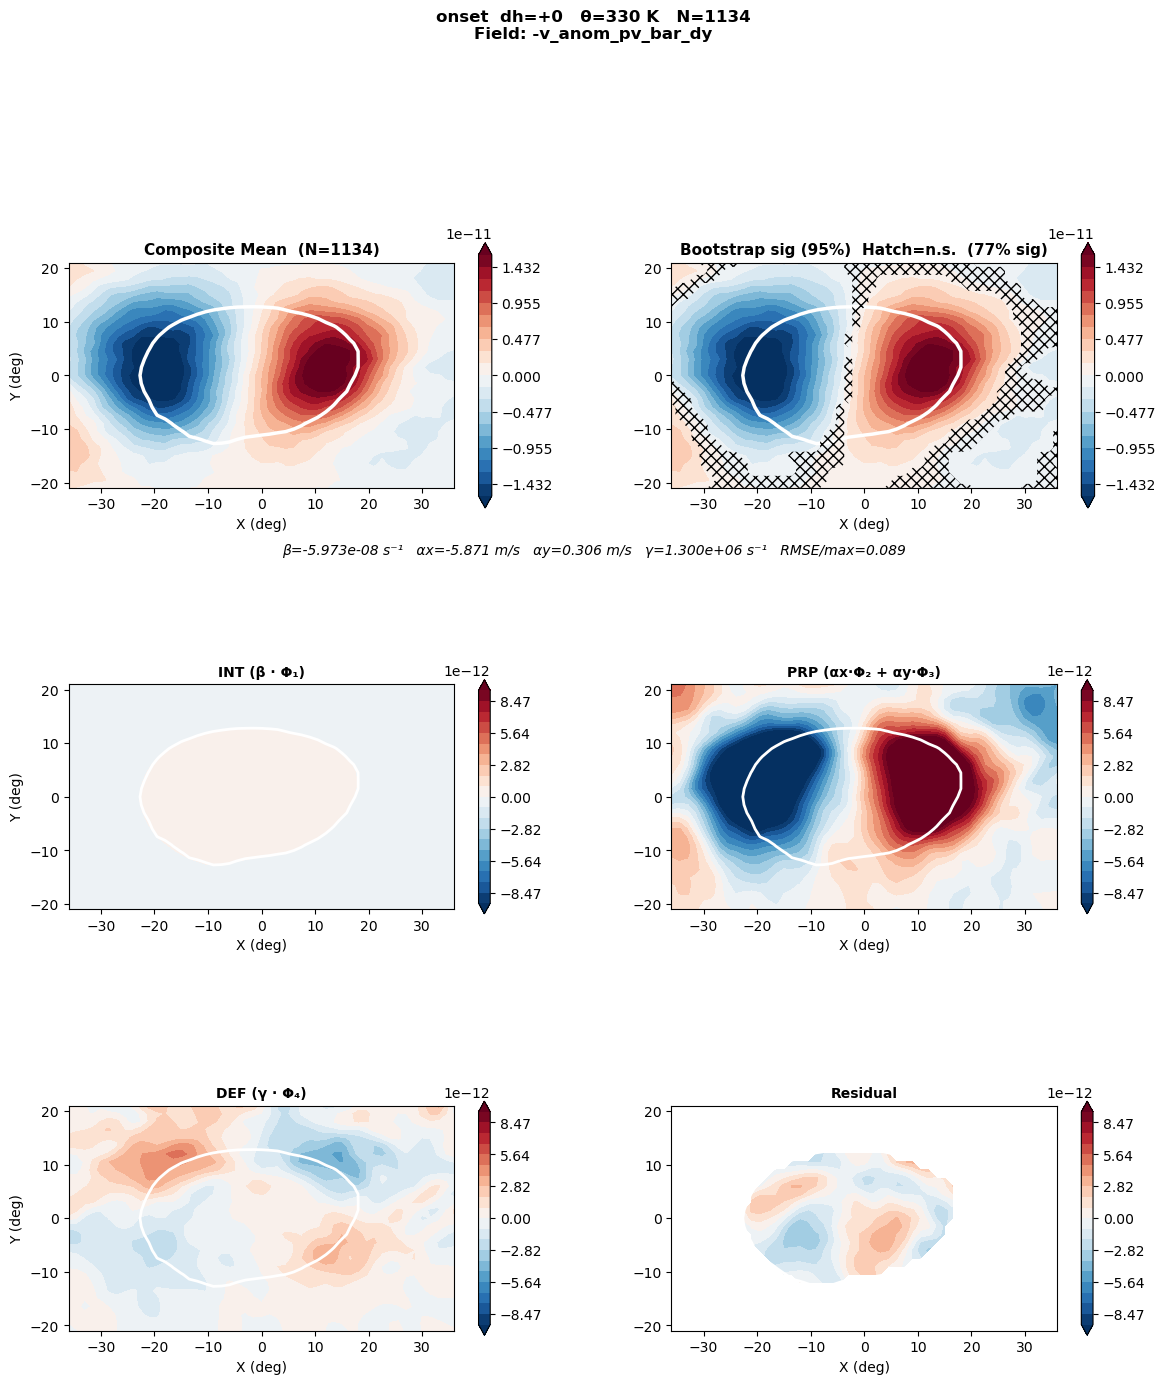

{'beta': -5.973064277315987e-08,
 'ax': -5.870591406095071,
 'ay': 0.3062640321135023,
 'gamma': 1299983.5596559842,
 'gamma_km2': 1.2999835596559841,
 'beta_raw': -5.973064277315987e-14,
 'ax_raw': -5.870591406095071e-12,
 'ay_raw': 3.062640321135023e-13,
 'gamma_raw': 1.2999835596559841e-12,
 'prop': array([[ 1.24343925e-12,  1.34781932e-12,  1.41296498e-12, ...,
         -1.15971563e-13,  2.49165387e-13,  5.20849990e-13],
        [ 1.27092669e-12,  1.52154567e-12,  1.60147602e-12, ...,
          5.45047578e-14,  3.21347338e-13,  5.21561932e-13],
        [ 1.45507043e-12,  1.91347513e-12,  1.95444913e-12, ...,
          8.06220101e-15,  7.04749182e-14,  1.70094958e-13],
        ...,
        [ 4.46136192e-12,  4.48820801e-12,  4.24630155e-12, ...,
         -6.15882549e-12, -5.28030147e-12, -4.52358744e-12],
        [ 4.98106746e-12,  4.86765272e-12,  4.40259889e-12, ...,
         -5.50235767e-12, -5.06364151e-12, -4.48231420e-12],
        [ 5.47243657e-12,  5.27681362e-12,  4.54217091

In [ ]:
# 6-panel: planetary vorticity advection on 330 K
plot_var(["-v_anom_pv_bar_dy"], dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1134, n_boot=1000, θ=330 K) ...
  Interpolating 1134 events to θ=330 K ...
  29.3% significant at 95%
  Projection (sig-only): β=2.403e-07  αx=-0.710  αy=-0.212  γ=-2.095e+04


/tmp/ipykernel_2777490/2899400677.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


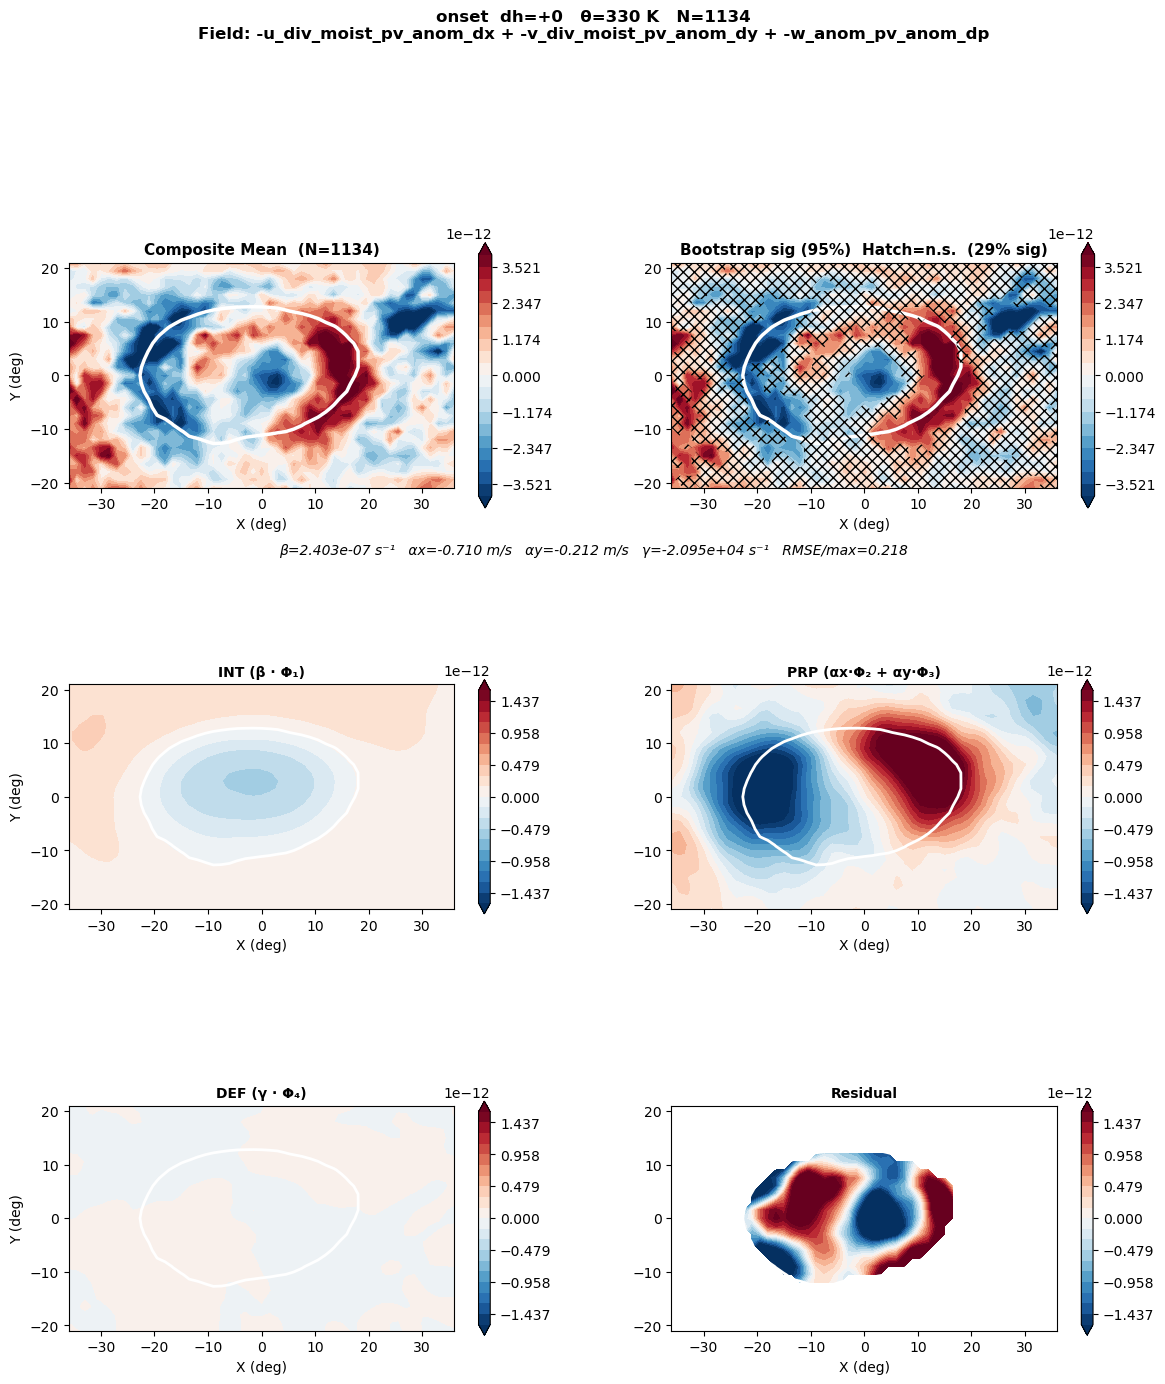

{'beta': 2.402508313417401e-07,
 'ax': -0.7103086355897674,
 'ay': -0.21178650690634718,
 'gamma': -20949.730467475896,
 'gamma_km2': -0.020949730467475895,
 'beta_raw': 2.402508313417401e-13,
 'ax_raw': -7.103086355897674e-13,
 'ay_raw': -2.1178650690634717e-13,
 'gamma_raw': -2.0949730467475896e-14,
 'prop': array([[ 2.27550405e-13,  2.42406074e-13,  2.55727663e-13, ...,
          1.73500513e-14,  6.42066069e-14,  1.05285037e-13],
        [ 2.24383718e-13,  2.63201839e-13,  2.81616185e-13, ...,
          4.12670060e-14,  7.45747152e-14,  9.91844167e-14],
        [ 2.50075616e-13,  3.16408829e-13,  3.26420170e-13, ...,
          4.17862930e-14,  3.98176720e-14,  4.16679137e-14],
        ...,
        [ 4.06016981e-13,  4.14400077e-13,  3.90820969e-13, ...,
         -6.54214716e-13, -5.41702250e-13, -4.46417101e-13],
        [ 4.76085204e-13,  4.65408538e-13,  4.11214476e-13, ...,
         -5.92464476e-13, -5.21035234e-13, -4.42629607e-13],
        [ 5.60081467e-13,  5.34198371e-13,  4.

In [ ]:
# 6-panel: moist-divergent + vertical eddy-eddy on 330 K
plot_var(["-u_div_moist_pv_anom_dx", "-v_div_moist_pv_anom_dy",
          "-w_anom_pv_anom_dp"], dh=0, theta_level=330, projection=True)

## Summary

- `plot_var(var_spec, dh, theta_level, projection)` is the main entry point.
- `var_spec` accepts field names with `-` prefix for negation; lists are summed.
- `theta_level` selects the isentropic surface (e.g. 315–355 K).
- Each event is interpolated from isobaric → isentropic **before** compositing,
  so the bootstrap CI is computed on the per-event θ slices.
- `projection=True` adds the 2×2 INT/PRP/DEF/Residual decomposition
  (6-panel figure); basis from the dh−1 composite on the same θ surface,
  projection uses **only bootstrapped-significant** grid points.
- White contour: PV anomaly = −0.5×10⁻⁶ PVU on the θ surface.